In [3]:
import os

In [4]:
#  Define the folder path
folder = r"C:\Users\user\Downloads"


files = os.listdir(folder)
uber_files = [f for f in files if "Uber" in f]

print(f"Files found in Downloads: {uber_files}")

Files found in Downloads: ['Dataset_Uber Traffic.csv']


In [5]:
if uber_files:
    target_file = os.path.join(folder, uber_files[0])
    df = pd.read_csv(target_file)
    print("Success! Dataframe loaded.")
    print(df.head())
else:
    print("No file with 'Uber' in the name was found in Downloads.")

Success! Dataframe loaded.
        DateTime  Junction  Vehicles           ID
0  01/11/15 0:00         1        15  20151101001
1  01/11/15 1:00         1        13  20151101011
2  01/11/15 2:00         1        10  20151101021
3  01/11/15 3:00         1         7  20151101031
4  01/11/15 4:00         1         9  20151101041


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

In [8]:

df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.drop_duplicates(subset="DateTime")       # Important for ARIMA
df = df.set_index("DateTime")
df = df.sort_index()

ts = df["Vehicles"].asfreq("H")
ts = ts.fillna(method="ffill")

# Train-validation split
split = int(len(ts)*0.8)
train, val = ts[:split], ts[split:]

In [9]:
# ------------------------------------------------
# 2. FIT MODEL WITH BEST ORDER FOUND EARLIER
# ------------------------------------------------
best_order = (2,1,2)
model = ARIMA(train, order=best_order)
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(val))

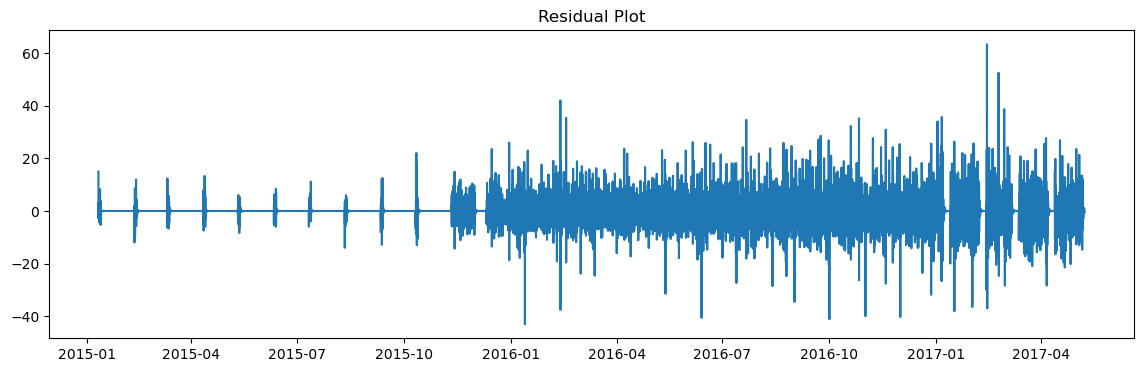

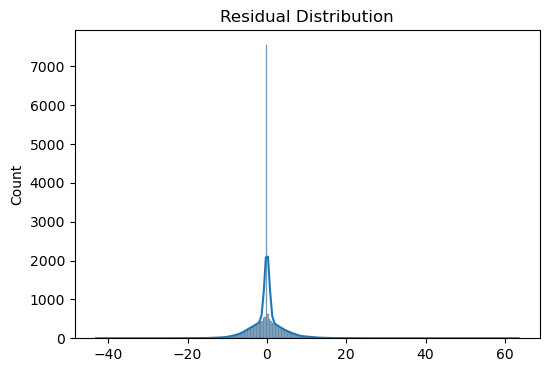

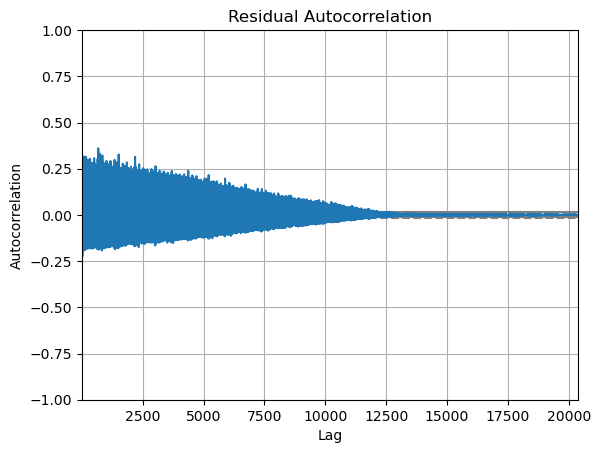

In [10]:
# ------------------------------------------------
# 4. RESIDUAL DIAGNOSTICS
# ------------------------------------------------
residuals = model_fit.resid

plt.figure(figsize=(14,4))
plt.plot(residuals)
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

pd.plotting.autocorrelation_plot(residuals)
plt.title("Residual Autocorrelation")
plt.show()


In [12]:
#ROLLING TIME-SERIES CROSS-VALIDATION
# ------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

cv_rmse_list = []

for train_index, test_index in tscv.split(ts):
    cv_train = ts.iloc[train_index]
    cv_test = ts.iloc[test_index]

    model = ARIMA(cv_train, order=best_order)
    m_fit = model.fit()

    pred = m_fit.forecast(steps=len(cv_test))
    fold_rmse = np.sqrt(mean_squared_error(cv_test, pred))
    cv_rmse_list.append(fold_rmse)

print("\n==== CROSS VALIDATION RESULTS ====")
print("RMSE per fold:", cv_rmse_list)
print("Average CV RMSE:", np.mean(cv_rmse_list))


==== CROSS VALIDATION RESULTS ====
RMSE per fold: [np.float64(6.309934121249968), np.float64(14.60277252711811), np.float64(17.102598171933543), np.float64(36.455897403433354), np.float64(17.663583065006502)]
Average CV RMSE: 18.426957057748297


In [13]:
# 6. FINAL MODEL REFINEMENT DIAGNOSIS
# ------------------------------------------------
print("\n==== MODEL REFINEMENT REPORT ====")

# Bias / Underfitting check
if residuals.mean() != 0:
    print("- Residuals show non-zero mean → possible bias.")
else:
    print("- Residuals centered → no bias detected.")

# Variance check
if np.abs(residuals).mean() > ts.std():
    print("- High residual variance → model may be underfitting.")
else:
    print("- Residual variance acceptable.")

# Autocorrelation check
print("- If residual autocorrelation plot shows spikes → ARIMA missing patterns.")



==== MODEL REFINEMENT REPORT ====
- Residuals show non-zero mean → possible bias.
- Residual variance acceptable.
- If residual autocorrelation plot shows spikes → ARIMA missing patterns.


In [14]:
# Peak hour errors
peak_errors = val.between_time("07:00", "09:00") - forecast[val.between_time("07:00", "09:00").index]
if peak_errors.mean() < -5:
    print("- Model underestimates morning peak traffic.")
elif peak_errors.mean() > 5:
    print("- Model overestimates morning peak traffic.")
else:
    print("- Peak-hour performance stable.")

- Model underestimates morning peak traffic.


In [15]:
# Weekend pattern check
weekday_val = val[val.index.weekday < 5]
weekend_val = val[val.index.weekday >= 5]

if weekday_val.mean() - weekend_val.mean() > 10:
    print("- Traffic pattern differs significantly between weekdays and weekends.")
    print("  ARIMA cannot capture categorical seasonality.")
else:
    print("- No major weekday/weekend pattern difference.")

- No major weekday/weekend pattern difference.


In [16]:
print("\n==== REFINEMENT SUGGESTIONS ====")
print("1. Use SARIMA for 24-hour and weekly seasonality.")
print("2. Try nonlinear models (LSTM, GRU, XGBoost).")
print("3. Add features: hour, day, lags, moving averages.")
print("4. Model each junction separately or use multivariate models.")
print("5. Apply rolling forecast origin evaluation for better stability.")


==== REFINEMENT SUGGESTIONS ====
1. Use SARIMA for 24-hour and weekly seasonality.
2. Try nonlinear models (LSTM, GRU, XGBoost).
3. Add features: hour, day, lags, moving averages.
4. Model each junction separately or use multivariate models.
5. Apply rolling forecast origin evaluation for better stability.
